# E-commerce OLAP Analysis

This notebook performs analytical queries on the transformed OLAP dataset generated from the OLTP database.

The goal is to extract insights from the Star Schema (Fact & Dimension tables).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## Load OLAP Tables

We load the fact table and dimension tables generated from the ETL process.

In [2]:
fact_sales = pd.read_csv('../output/fact_sales.csv')
dim_time = pd.read_csv('../output/dim_time.csv')
dim_product = pd.read_csv('../output/dim_product.csv')
dim_branch = pd.read_csv('../output/dim_branch.csv')

## Preview Data

Let's take a quick look at the data structure.

In [3]:
fact_sales.head()

,sales_key,order_id,order_item_id,date_key,customer_key,product_key,branch_key,payment_method_key,currency_key,quantity,unit_sale_price,unit_purchase_price,gross_sales,total_cost,profit,allocated_tax_amount,allocated_total_amount,status
0,1,1,1,20260323,145,28,2,2.0,3,1,1318.17,922.72,1318.17,922.72,395.45,478.1875,3666.1025,shipped
1,2,1,2,20260323,145,234,2,2.0,3,1,1245.72,872.00,1245.72,872.00,373.72,478.1875,3666.1025,shipped
2,3,1,3,20260323,145,194,2,2.0,3,2,3168.38,2217.87,6336.76,4435.74,1901.02,478.1875,3666.1025,shipped
3,4,1,4,20260323,145,114,2,2.0,3,3,1283.67,898.57,3851.01,2695.71,1155.30,478.1875,3666.1025,shipped
4,5,2,5,20260223,54,51,4,NaN,1,1,314.76,220.33,314.76,220.33,94.43,245.7850,1884.3550,cancelled


## Total Sales

This shows the overall sales generated from all transactions.

In [4]:
total_sales = fact_sales['gross_sales'].sum()
total_sales

np.float64(3271883.9400000004)

## Total Profit

This shows the total profit after subtracting costs from sales.

In [5]:
total_profit = fact_sales['profit'].sum()
total_profit

np.float64(981565.72)

## Sales by Branch

This analysis shows which branch generates the highest revenue.

In [6]:
sales_by_branch = fact_sales.groupby('branch_key')['gross_sales'].sum().sort_values(ascending=False)
sales_by_branch

branch_key
4    868853.21
3    823077.00
1    802324.81
2    777628.92
Name: gross_sales, dtype: float64

## Top 5 Products by Sales

This shows the best-performing products based on sales.

In [7]:
top_products = (
    fact_sales.groupby('product_key')['gross_sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_products

product_key
178    49862.55
76     48160.61
108    43212.35
82     40781.51
56     40489.11
Name: gross_sales, dtype: float64

## Sales Over Time (Monthly)

We join the fact table with the time dimension to analyze sales trends over months.

In [8]:
merged = fact_sales.merge(dim_time, on='date_key')

sales_by_month = merged.groupby('month')['gross_sales'].sum().sort_index()
sales_by_month

month
1     497025.10
2     907701.13
3    1206103.26
4     661054.45
Name: gross_sales, dtype: float64

## Sales by Month Visualization

This bar chart shows how sales change over time.

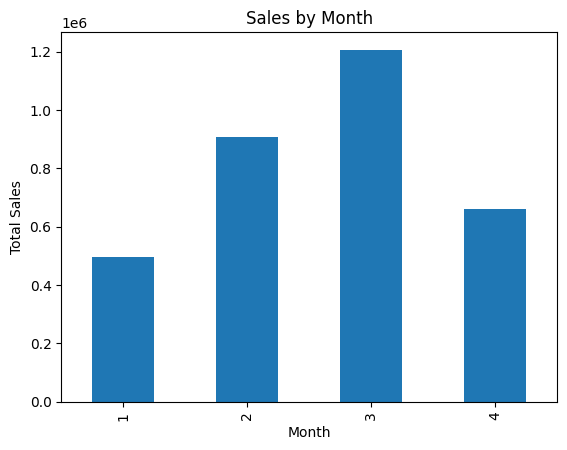

In [9]:
sales_by_month.plot(kind='bar')
plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

## Insights

- The OLTP data was successfully transformed into an OLAP model.
- The Star Schema enables fast and simple analysis.
- Sales and profit metrics are easily calculated.
- The model allows analysis by product, branch, and time.

This demonstrates the power of OLAP systems for decision-making.